In [1]:
import numpy as np
import pickle

with open('/Users/suthardr/Desktop/collection_fc_allmice.pkl', 'rb') as file:
    collection_fc = pickle.load(file)

with open('/Users/suthardr/Desktop/collection_cxta_allmice.pkl', 'rb') as file:
    collection_cxta = pickle.load(file)


In [40]:
table = collection_fc.animals['astroF7'].registration_tables['FC-A']
table

array([[  0,  25],
       [  1,  -1],
       [  2,  -1],
       [  3,  -1],
       [  4,  -1],
       [  5,  -1],
       [  6,  -1],
       [  7,  -1],
       [  8,   3],
       [  9,   4],
       [ 10,  -1],
       [ 11,  -1],
       [ 12,   9],
       [ 13,  -1],
       [ 14,  -1],
       [ 15,  -1],
       [ 16,  -1],
       [ 17,  -1],
       [ 18,  -1],
       [ 19,  16],
       [ 20,  -1],
       [ 21,  -1],
       [ 22,  -1],
       [ 23,  -1],
       [ 24,  -1],
       [ 25,  -1],
       [ 26,  19],
       [ 27,  -1],
       [ 28,  -1],
       [ 29,  -1],
       [ 30,  -1],
       [ 31,  -1],
       [ 32,  -1],
       [ 33,  -1],
       [ 34,  -1],
       [ 35,  17],
       [ 36,  -1],
       [ 37,  -1],
       [ 38,  20],
       [ 39,  -1],
       [ 40,  -1],
       [ 41,  -1],
       [ 42,  -1],
       [ 43,  -1],
       [ 44,  18],
       [ 45,  -1],
       [ 46,  -1],
       [ 47,  -1],
       [ 48,  11],
       [ 49,  -1],
       [ 50,  -1],
       [ 51,  -1],
       [ 52,

In [41]:
# rows where both FC and CxtA exist
valid_rows = np.where((table[:, 0] != -1) & (table[:, 1] != -1))[0]
valid_rows

array([  0,   8,   9,  12,  19,  26,  35,  38,  44,  48,  73,  77,  79,
        84, 110, 120, 123, 129])

In [42]:
# collect the actual row indices for each recording
fc_idx     = table[valid_rows, 0].astype(int)
fc_idx

array([  0,   8,   9,  12,  19,  26,  35,  38,  44,  48,  73,  77,  79,
        84, 110, 120, 123, 129])

In [43]:
recall_idx = table[valid_rows, 1].astype(int)
recall_idx

array([25,  3,  4,  9, 16, 19, 17, 20, 18, 11, 21, 26, 10,  1, 29, 30,  0,
        2])

In [46]:
fc_traces = collection_fc.animals['astroF7'].accepted_traces.to_numpy().T
fc_traces

array([[ 0.00188352, -0.0006621 , -0.00087986, ...,  0.00074708,
         0.00103646,  0.00153369],
       [ 0.00227408,  0.00134628,  0.00045145, ...,  0.00067933,
         0.0013257 , -0.00020963],
       [ 0.00011793,  0.0005171 ,  0.00072558, ...,  0.00021206,
         0.00051997, -0.00031276],
       ...,
       [ 0.00118487,  0.00172246,  0.00043313, ...,  0.00252485,
         0.00064526,  0.00186934],
       [-0.0041388 , -0.00038787,  0.00150271, ...,  0.00209367,
         0.00183365,  0.00184618],
       [ 0.00504661,  0.00353099,  0.00425391, ...,  0.00224851,
         0.00153487,  0.00032988]])

In [47]:
recall_traces = collection_cxta.animals['astroF7'].accepted_traces.to_numpy().T #this is cell x time
recall_traces

array([[ 0.01857856,  0.01304623,  0.00906044, ...,  0.00156613,
         0.00292324,  0.00331316],
       [ 0.03009842,  0.01901323,  0.01819047, ...,  0.0015356 ,
         0.00146369, -0.00097764],
       [ 0.01006347,  0.00571257,  0.00651041, ...,  0.00196579,
         0.0019354 ,  0.00285364],
       ...,
       [ 0.00899879,  0.00538578,  0.00299982, ...,  0.00257964,
         0.00234079,  0.00128198],
       [ 0.01301271,  0.00693994,  0.00492522, ...,  0.00395227,
         0.00491641,  0.00323703],
       [ 0.00831777,  0.00296259,  0.00450669, ...,  0.0020037 ,
         0.00304121,  0.00142532]])

In [48]:
fc_active     = fc_traces[fc_idx, :]
fc_active

array([[ 1.88352223e-03, -6.62102991e-04, -8.79859577e-04, ...,
         7.47082531e-04,  1.03645926e-03,  1.53369370e-03],
       [ 3.13355994e-03,  1.52947598e-03,  5.94548621e-04, ...,
         2.09185564e-03,  9.75332886e-04,  2.12867103e-03],
       [ 1.54917626e-03,  2.75371233e-03,  2.13443626e-03, ...,
         3.04526637e-03,  2.57504787e-03,  3.15094398e-03],
       ...,
       [ 4.73199058e-05,  9.75260541e-04,  1.39942651e-03, ...,
         2.40971025e-03,  8.37990504e-04,  1.14498238e-03],
       [ 6.21194443e-03,  4.10394985e-03,  3.64081930e-03, ...,
         3.04496418e-03,  2.37376628e-03,  4.50361916e-04],
       [ 5.04660921e-03,  3.53098567e-03,  4.25391370e-03, ...,
         2.24850990e-03,  1.53487234e-03,  3.29881742e-04]])

In [49]:
    # rows by position
recall_active = recall_traces[recall_idx, :]

In [50]:
recall_active

array([[0.00700737, 0.00622928, 0.00505406, ..., 0.00155794, 0.00047921,
        0.00141595],
       [0.01722575, 0.00968476, 0.00558796, ..., 0.00380169, 0.00286098,
        0.00247359],
       [0.00607293, 0.00606847, 0.00657124, ..., 0.00221847, 0.00452794,
        0.00258799],
       ...,
       [0.01301271, 0.00693994, 0.00492522, ..., 0.00395227, 0.00491641,
        0.00323703],
       [0.01857856, 0.01304623, 0.00906044, ..., 0.00156613, 0.00292324,
        0.00331316],
       [0.01006347, 0.00571257, 0.00651041, ..., 0.00196579, 0.0019354 ,
        0.00285364]])

In [51]:
from scipy import stats
fc_dfz = stats.zscore(fc_active, axis=1)
recall_dfz = stats.zscore(recall_active, axis=1)

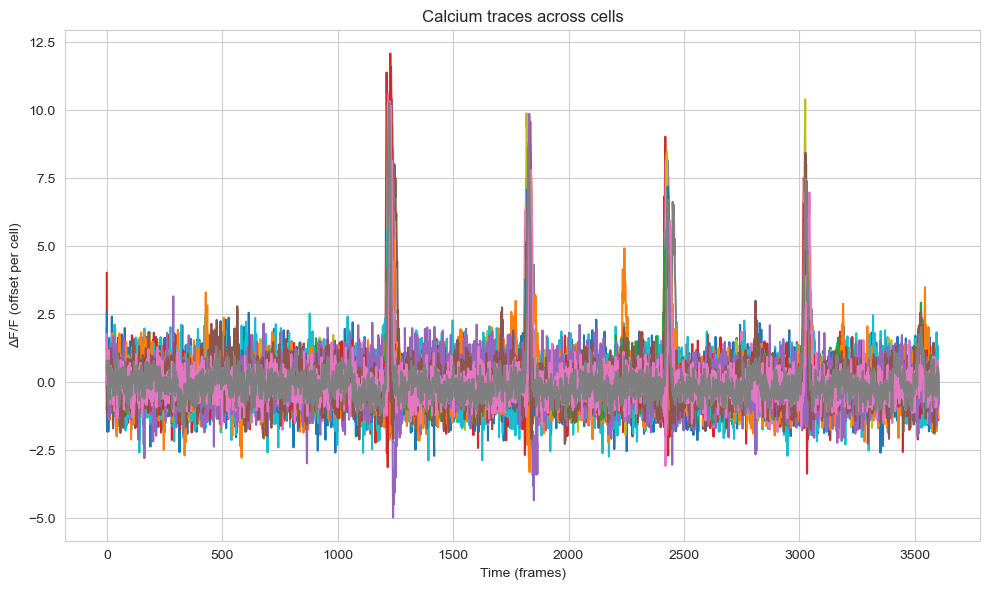

In [52]:
import matplotlib.pyplot as plt
data = fc_dfz
plt.figure(figsize=(10, 6))
for i in range(data.shape[0]):
    plt.plot(data[i, :],label=f'Cell {i}')  # offset each cell vertically
plt.xlabel('Time (frames)')
plt.ylabel('ΔF/F (offset per cell)')
plt.title('Calcium traces across cells')
plt.tight_layout()
plt.show()

In [53]:
import onep
time = collection_fc.animals['astroF7'].Timestamps.to_numpy().squeeze()

across_eta_, time_fc = onep.eta_individual_cells(
    data=fc_dfz,
    timestamps=time,
    events=[[120, 180, 240, 300]],  # detected onsets
    window=15
)

across_eta_R, time_R = onep.eta_individual_cells(
    data=recall_dfz,
    timestamps=time,
    events=[[]],
    window=15
)
#astroM3 - 71.9448772796669, 224.9276649396253, 266.7955865787648

#astroM4-121.5068386007773, 171.4685321043864, 243.9129876846197,
       #285.4811166796225

#astroM5 - 34.67342136063298, 89.83114064325375, 173.8667238256524

#astroM6 - 84.73501601221373,  148.286278021374, 174.9658172610687,
       #266.6954690290077

#astroM7 - 43.16693610899183,  118.509227373297, 229.5241950054496,
       #266.8955702479564

#astroM8 - 91.42997888754353,133.3978380490389,248.8094507431512,  275.489018352959

#astroM9 - 67.54823800666061, 111.5145467683924, 143.0903503336361

In [54]:
time_fc

array([-7.5       , -7.39955357, -7.29910714, -7.19866071, -7.09821429,
       -6.99776786, -6.89732143, -6.796875  , -6.69642857, -6.59598214,
       -6.49553571, -6.39508929, -6.29464286, -6.19419643, -6.09375   ,
       -5.99330357, -5.89285714, -5.79241071, -5.69196429, -5.59151786,
       -5.49107143, -5.390625  , -5.29017857, -5.18973214, -5.08928571,
       -4.98883929, -4.88839286, -4.78794643, -4.6875    , -4.58705357,
       -4.48660714, -4.38616071, -4.28571429, -4.18526786, -4.08482143,
       -3.984375  , -3.88392857, -3.78348214, -3.68303571, -3.58258929,
       -3.48214286, -3.38169643, -3.28125   , -3.18080357, -3.08035714,
       -2.97991071, -2.87946429, -2.77901786, -2.67857143, -2.578125  ,
       -2.47767857, -2.37723214, -2.27678571, -2.17633929, -2.07589286,
       -1.97544643, -1.875     , -1.77455357, -1.67410714, -1.57366071,
       -1.47321429, -1.37276786, -1.27232143, -1.171875  , -1.07142857,
       -0.97098214, -0.87053571, -0.77008929, -0.66964286, -0.56

In [55]:
across_eta_

array([[-0.82641428, -0.54334139, -0.45094297, ..., -0.30145948,
        -0.82565468, -0.88867521],
       [ 0.113752  , -0.26661943, -0.35128904, ..., -0.15204703,
        -0.30745572, -0.31637945],
       [-0.0462311 , -0.20921491, -0.29797487, ..., -0.21321041,
        -0.06003646, -0.40125545],
       ...,
       [-0.00225908, -0.36789317, -0.23484184, ..., -0.1330921 ,
        -0.21059286, -0.19245061],
       [-0.1496738 ,  0.00612262, -0.1550077 , ..., -0.17889524,
         0.05033262, -0.11865998],
       [-0.46106752, -0.33337356, -0.34318311, ..., -0.20181724,
        -0.10200975, -0.24972374]])

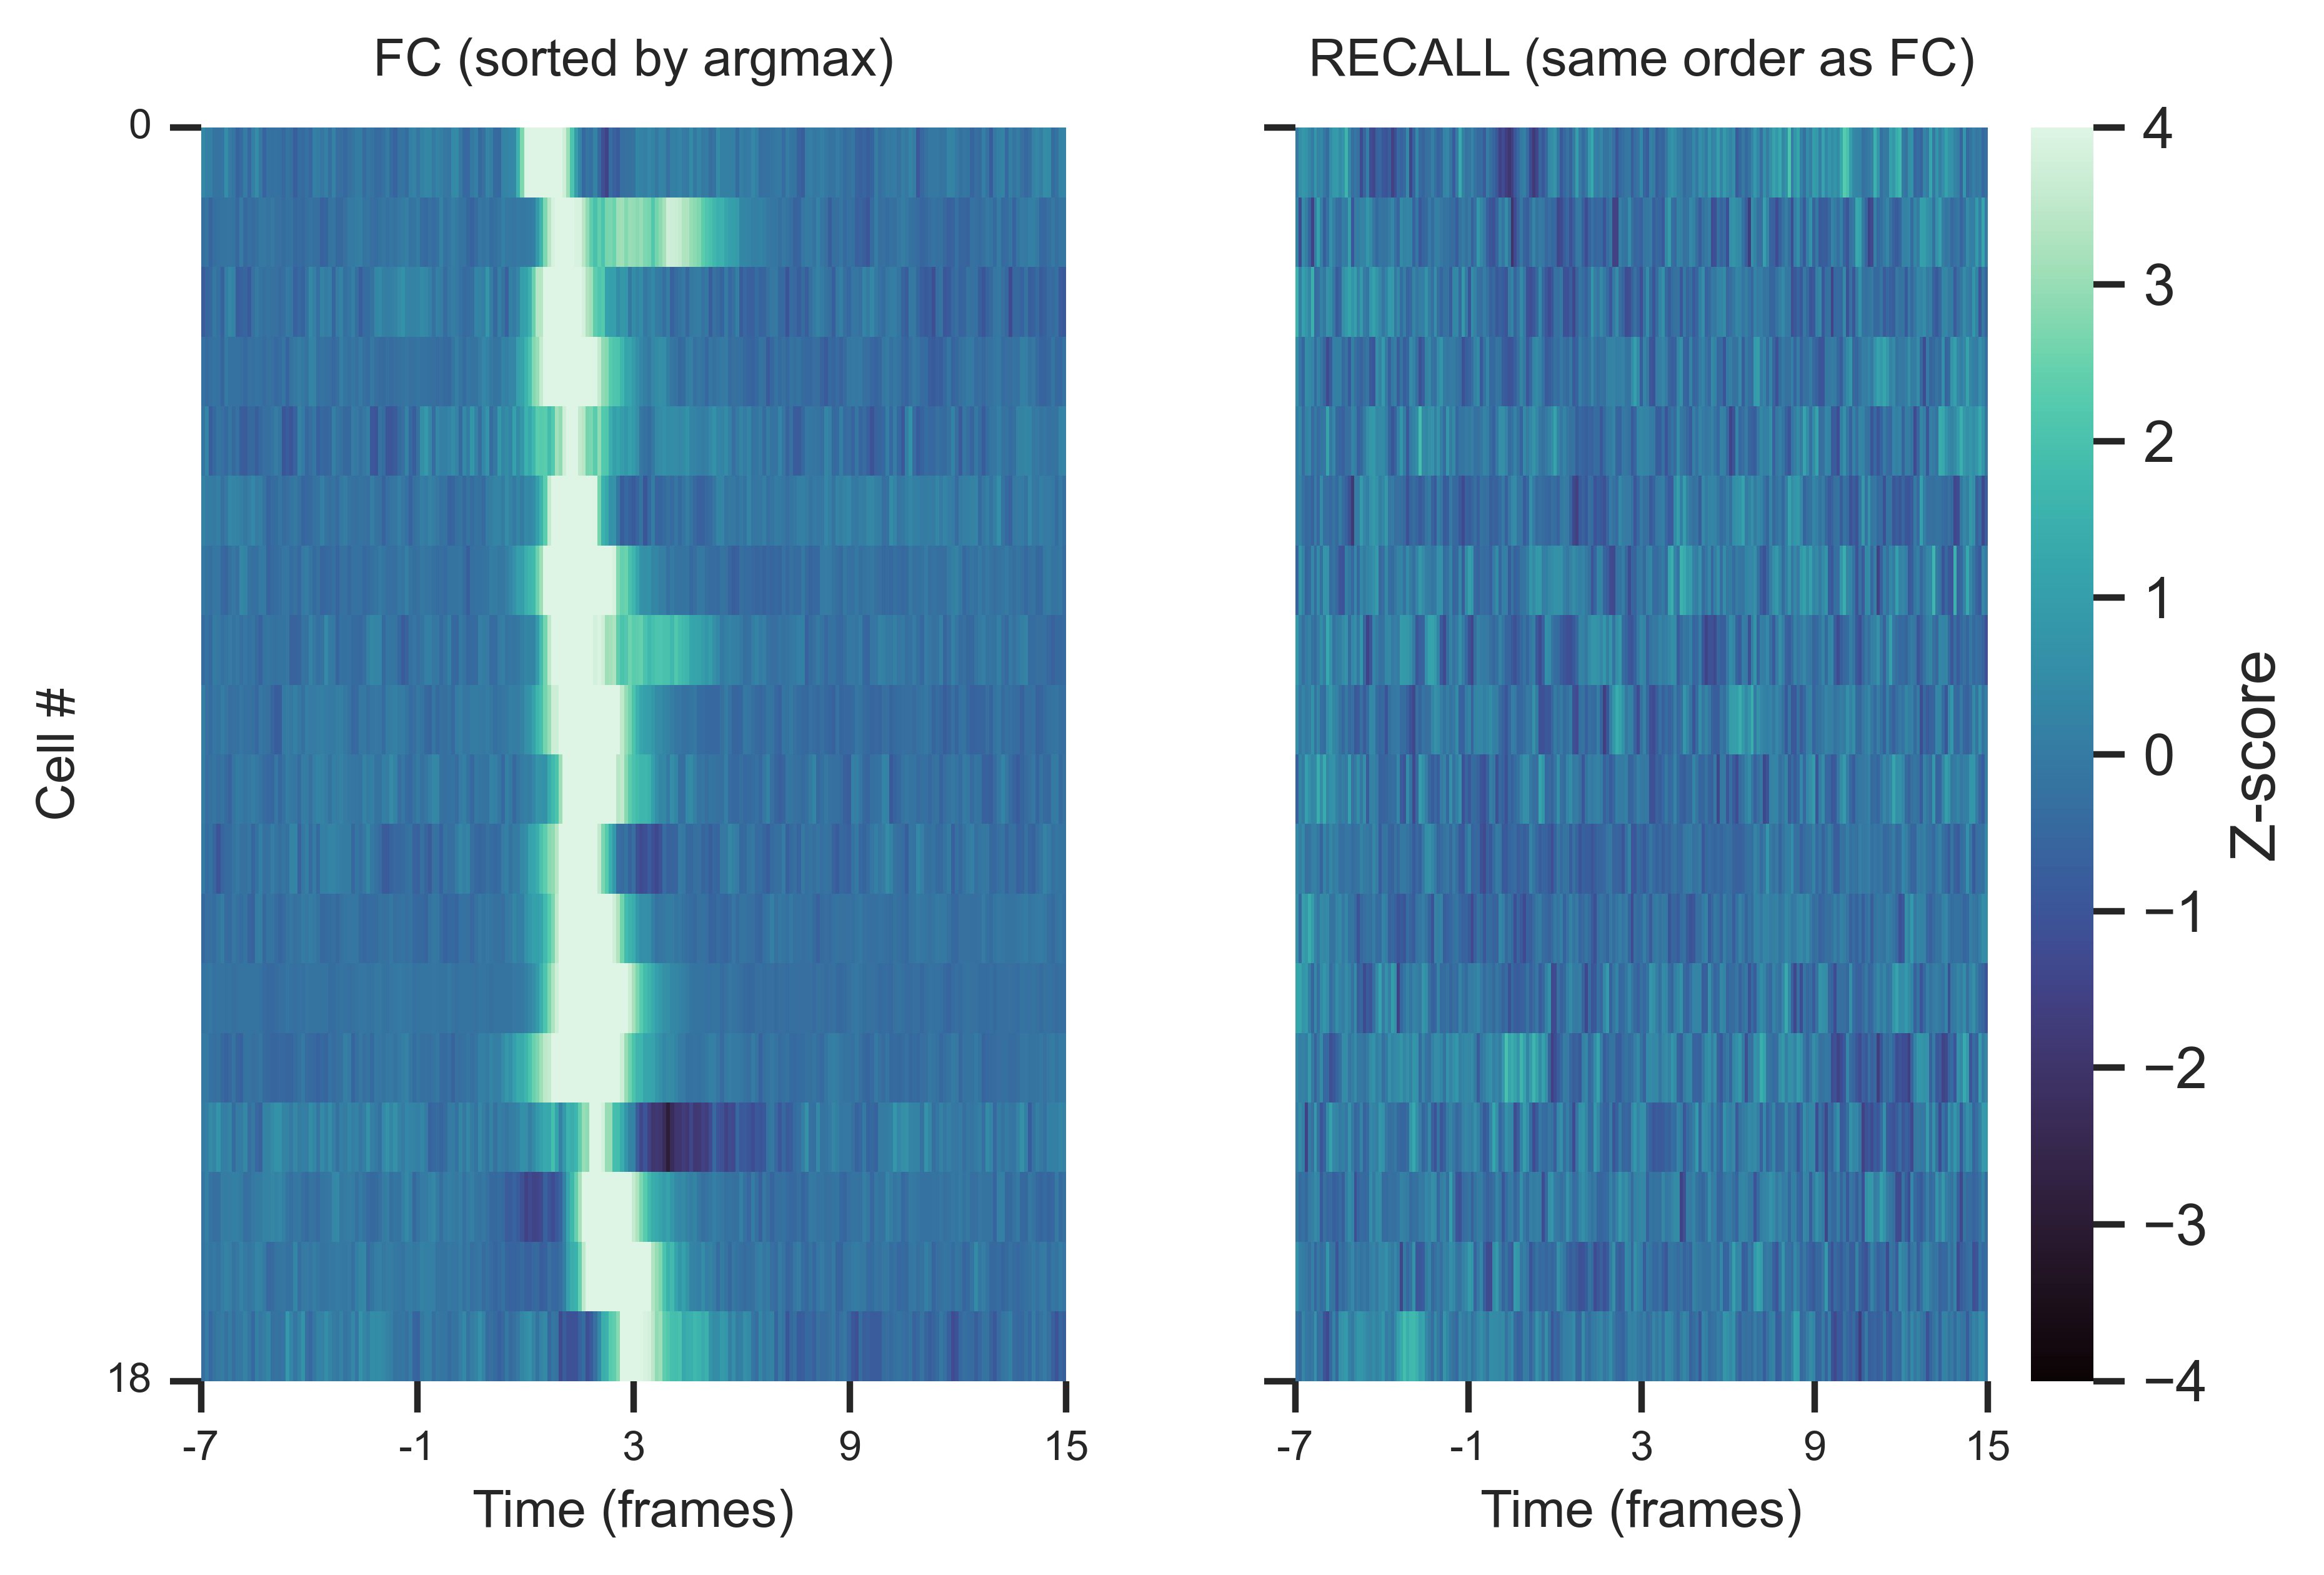

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- sort by Day 1 argmax ---
order = np.argmax(across_eta_, axis=1).argsort()
time= time_fc
fc_sorted = across_eta_[order]
recall_sorted = across_eta_R[order]

# --- figure aesthetics matching your original ---
sns.set(style="ticks", font="Arial")
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(7, 5), dpi=600)

vmin, vmax = -4, 4
first_last = [0, across_eta_.shape[0]]

# --- FC heatmap (Day 1) ---
sns.heatmap(fc_sorted, ax=ax1, cmap='mako', cbar=False,
            xticklabels=True, rasterized=True, yticklabels=True,
            vmin=vmin, vmax=vmax)
ax1.tick_params(axis='both', which='major', labelsize=8)
ax1.set_xticks(np.linspace(0, len(time), 5))
ax1.set_xticklabels(np.linspace(time.min(), time.max(), 5).astype(int), rotation=0)
ax1.set_yticks(first_last)
ax1.set_yticklabels([first_last[0], first_last[1]], rotation=0)
ax1.set_title('FC (sorted by argmax)', fontsize=10, pad=10)
ax1.set_ylabel('Cell #', fontsize=10)
ax1.set_xlabel('Time (frames)', fontsize=10)
sns.despine(ax=ax1, left=True, bottom=True)

# --- RECALL heatmap (Day 2) ---
sns.heatmap(recall_sorted, ax=ax2, cmap='mako', cbar=True,
            cbar_kws={'label': 'Z-score'}, xticklabels=True,
            rasterized=True, yticklabels=True, vmin=vmin, vmax=vmax)
ax2.tick_params(axis='both', which='major', labelsize=8)
ax2.set_xticks(np.linspace(0, len(time), 5))
ax2.set_xticklabels(np.linspace(time.min(), time.max(), 5).astype(int), rotation=0)
ax2.set_yticks(first_last)
ax2.set_yticklabels([first_last[0], first_last[1]], rotation=0)
ax2.set_title('RECALL (same order as FC)', fontsize=10, pad=10)
ax2.set_xlabel('Time (frames)', fontsize=10)
sns.despine(ax=ax2, left=True, bottom=True)

plt.tight_layout(pad=3)
plt.show()